In [126]:
%load_ext autoreload
%autoreload 2

from plot import load_outputs, plot_final_loss_vs_lr, plot_tuned_curves
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import json, glob, statistics
import numpy as np

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='cm')
plt.rc('legend', fontsize=10)

colormap = {
    'muon':       '#8A2BE2',
    'adamw':      '#FF6B35',
    'dap-opnorm': '#1f77b4',
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
import yaml, copy
from gptopt.utils import hash_config

def best_val(run):
    return min(run['val_losses'])

def load_sweep(config_file, sweep_param):
    """Load outputs for a sweep config, labeling each run by its sweep param value.
    Mimics run.py's hash_config call order exactly (mb_subsampling set after first hash).
    """
    with open(config_file) as f:
        cfg = yaml.safe_load(f)
    training_params = cfg['training_params']
    gpt_model = cfg['gpt_model']
    output_dir = 'gptopt/outputs/' + config_file.replace('configs/', '').replace('.yaml', '')
    results = []
    for opt_config in cfg['optimizer_params']:
        for lr in opt_config['lr']:
            occ = copy.deepcopy(opt_config)
            occ['lr'] = lr
            h = hash_config(occ, training_params, gpt_model)
            schedule = opt_config.get('lr_schedule', 'warm-up-cosine')
            fname = f"{output_dir}/dap-opnorm-lr-{lr}-{schedule}-{h}-world1.json"
            files = glob.glob(fname)
            if not files:
                print(f"Not found: {fname}")
            else:
                d = json.load(open(files[0]))
                d['_label'] = f"{sweep_param}={opt_config.get(sweep_param, 'none')}"
                results.append(d)
            training_params['mb_subsampling'] = None  # mimic run.py ordering
    return results

def load_diag_outputs(*patterns):
    """Load JSON outputs that contain diagnostics."""
    results = []
    for pat in patterns:
        for f in sorted(glob.glob(pat)):
            d = json.load(open(f))
            if 'diagnostics' in d and d['diagnostics']:
                results.append(d)
    return results

def plot_diag_over_steps(outputs, key='C_inv_sqrt_opnorm', ax=None, per_layer_agg=np.mean, label_fn=None):
    """Plot a diagnostic (aggregated over layers) vs optimizer step."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    for run in outputs:
        diag = run['diagnostics'].get(key)
        if not diag:
            continue
        step_means = [per_layer_agg(vals) for vals in diag]
        label = label_fn(run) if label_fn else run['name']
        ax.plot(step_means, label=label)
    ax.set_xlabel('Optimizer step')
    ax.set_ylabel(key)
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(axis='both', lw=0.2, ls='--')
    return ax

## LR Sensitivity: Muon vs DAPOpNorm vs AdamW

In [128]:
# Combine baseline + extended outputs for each method
outputs = []
for pattern in [
    'gptopt/outputs/finewebmini/dap_opnorm_muon_baseline/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm_muon_extended/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm_adamw_baseline/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm_adamw_extended/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm_extended/*.json',
]:
    for f in glob.glob(pattern):
        with open(f) as fh:
            outputs.append(json.load(fh))

print(f'Loaded {len(outputs)} runs')
for o in sorted(outputs, key=lambda x: (x['name'].split('-lr-')[0], float(x['name'].split('-lr-')[1]))):
    name, lr = o['name'].split('-lr-')
    print(f'  {name:20s}  lr={lr:6s}  best_val={min(o["val_losses"]):.4f}')

Loaded 60 runs
  adamw                 lr=0.0003  best_val=6.1076
  adamw                 lr=0.0003  best_val=6.1064
  adamw                 lr=0.0003  best_val=6.1065
  adamw                 lr=0.0006  best_val=5.7580
  adamw                 lr=0.0006  best_val=5.7596
  adamw                 lr=0.0006  best_val=5.7567
  adamw                 lr=0.001   best_val=5.4909
  adamw                 lr=0.001   best_val=5.4984
  adamw                 lr=0.001   best_val=5.4918
  adamw                 lr=0.002   best_val=5.2480
  adamw                 lr=0.002   best_val=5.2605
  adamw                 lr=0.002   best_val=5.2628
  adamw                 lr=0.003   best_val=5.2452
  adamw                 lr=0.003   best_val=5.2136
  adamw                 lr=0.003   best_val=5.1674
  adamw                 lr=0.005   best_val=5.7196
  adamw                 lr=0.005   best_val=5.6927
  adamw                 lr=0.005   best_val=5.7080
  dap-opnorm            lr=0.001   best_val=5.5889
  dap-opnorm    

Loaded 5 runs (damping=0.005):
  dap-opnorm-d0.005-lr-0.02                 best_val=4.6814
  dap-opnorm-d0.005-lr-0.03                 best_val=4.5930
  dap-opnorm-d0.005-lr-0.05                 best_val=4.7469
  dap-opnorm-d0.005-lr-0.07                 best_val=4.7143
  dap-opnorm-d0.005-lr-0.1                  best_val=4.7935
Loaded 10 runs (ema=0.99):
  dap-opnorm-ema0.99-lr-0.005               best_val=5.0465
  dap-opnorm-ema0.99-lr-0.007               best_val=4.9701
  dap-opnorm-ema0.99-lr-0.01                best_val=4.8333
  dap-opnorm-ema0.99-lr-0.015               best_val=4.7570
  dap-opnorm-ema0.99-lr-0.02                best_val=4.6340
  dap-opnorm-ema0.99-lr-0.03                best_val=4.7312
  dap-opnorm-ema0.99-lr-0.04                best_val=4.7632
  dap-opnorm-ema0.99-lr-0.05                best_val=4.8070
  dap-opnorm-ema0.99-lr-0.07                best_val=4.8308
  dap-opnorm-ema0.99-lr-0.1                 best_val=4.8331
Loaded 5 runs (d=0.001+ema):
  dap-opnorm-

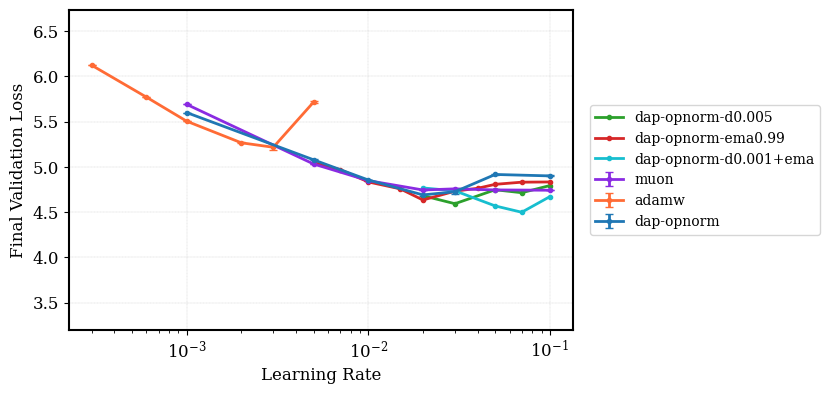

In [129]:
import os, re
os.makedirs('figures', exist_ok=True)

hydra_base = 'outputs/gpt-tiny/finewebmini/dap-opnorm'

def load_hydra_sweep(label, ema_beta=None, damping=None):
    """Load Hydra LR sweep runs matching given ema_beta and damping.
    Pass None to match runs with no hyperparams saved (pre-fix runs).
    """
    results = []
    for f in sorted(glob.glob(hydra_base + '/bs-256-lr-*-wd-0.1/dap-opnorm-lr-*-world1.json')):
        d = json.load(open(f))
        hp = d.get('hyperparams')
        if ema_beta is None and damping is None:
            if hp is not None:
                continue  # only match pre-fix runs with no hyperparams
        else:
            if hp is None:
                continue
            if hp.get('ema_beta') != ema_beta or hp.get('damping') != damping:
                continue
        lr_match = re.search(r'bs-256-lr-([0-9.]+)-wd', f)
        lr = float(lr_match.group(1))
        d = dict(d)
        d['name'] = f'{label}-lr-{lr}'
        results.append(d)
    return results

# --- switchable damping value ---
damping_val = 0.005

d_sweep_outputs    = load_hydra_sweep(f'dap-opnorm-d{damping_val}', ema_beta=0.0, damping=damping_val)
ema_outputs        = load_hydra_sweep('dap-opnorm-ema0.99', ema_beta=0.99, damping=0.0)
d001_ema_outputs   = load_hydra_sweep('dap-opnorm-d0.001+ema', ema_beta=0.99, damping=0.001)

for tag, runs in [(f'damping={damping_val}', d_sweep_outputs), ('ema=0.99', ema_outputs), ('d=0.001+ema', d001_ema_outputs)]:
    print(f'Loaded {len(runs)} runs ({tag}):')
    for o in runs:
        print(f"  {o['name']:40s}  best_val={min(o['val_losses']):.4f}")

outputs_plus = list(outputs) + d_sweep_outputs + ema_outputs + d001_ema_outputs

colormap_ext = {
    **colormap,
    f'dap-opnorm-d{damping_val}': '#2ca02c',
    'dap-opnorm-ema0.99':         '#d62728',
    'dap-opnorm-d0.001+ema':      '#17becf',
}

plot_final_loss_vs_lr(outputs_plus, colormap_ext, outfilename='dap_opnorm_finewebmini', val=True)
plt.show()

## Best-tuned Loss Curves

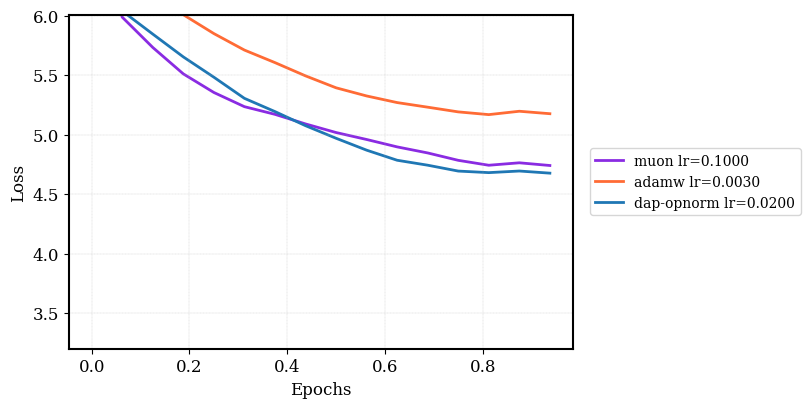

In [130]:
plot_tuned_curves(outputs, colormap, outfilename='dap_opnorm_finewebmini', val=True, wallclock=False, num_epochs=1)
plt.show()

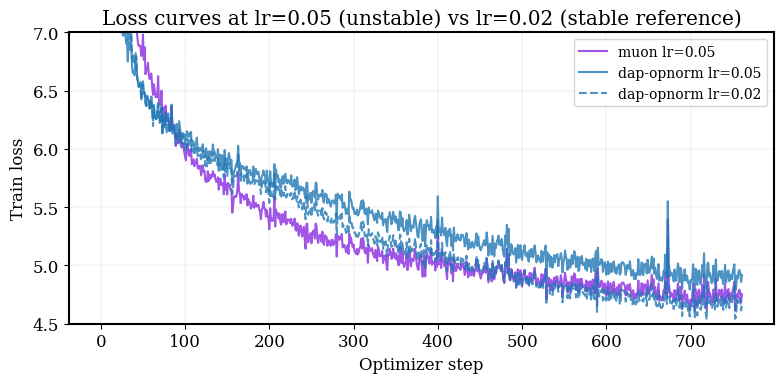

In [131]:
fig, ax = plt.subplots(figsize=(8, 4))

for pattern, label, color in [
    ('gptopt/outputs/finewebmini/dap_opnorm_muon_extended/*lr-0.05*world1.json', 'muon lr=0.05', '#8A2BE2'),
    ('gptopt/outputs/finewebmini/dap_opnorm_extended/*lr-0.05*world1.json',      'dap-opnorm lr=0.05', '#1f77b4'),
    ('gptopt/outputs/finewebmini/dap_opnorm/*lr-0.02*world1.json',              'dap-opnorm lr=0.02', '#1f77b4'),
]:
    files = [f for f in glob.glob(pattern) if 'seed' not in f]
    if not files:
        print(f'No file found for: {pattern}')
        continue
    d = json.load(open(files[0]))
    ls = '--' if 'lr=0.02' in label else '-'
    ax.plot(d['losses'], label=label, color=color, ls=ls, alpha=0.8)

ax.set_xlabel('Optimizer step')
ax.set_ylabel('Train loss')
ax.set_ylim(4.5, 7.0)
ax.legend()
ax.grid(axis='both', lw=0.2, ls='--')
ax.set_title('Loss curves at lr=0.05 (unstable) vs lr=0.02 (stable reference)')
plt.tight_layout()
plt.show()

## Diagnostics: C_inv_sqrt operator norm over training steps

In [132]:
diag_outputs = load_diag_outputs(
    'gptopt/outputs/finewebmini/dap_opnorm/*.json',
    'gptopt/outputs/finewebmini/dap_opnorm_extended/*.json',
)
print(f'Loaded {len(diag_outputs)} runs with diagnostics')
for o in diag_outputs:
    name, lr = o['name'].split('-lr-')
    nsteps = len(o['diagnostics'].get('C_inv_sqrt_opnorm', []))
    print(f'  {name}  lr={lr}  steps_with_diag={nsteps}')

Loaded 7 runs with diagnostics
  dap-opnorm  lr=0.001  steps_with_diag=762
  dap-opnorm  lr=0.005  steps_with_diag=762
  dap-opnorm  lr=0.01  steps_with_diag=762
  dap-opnorm  lr=0.02  steps_with_diag=762
  dap-opnorm  lr=0.03  steps_with_diag=762
  dap-opnorm  lr=0.05  steps_with_diag=762
  dap-opnorm  lr=0.1  steps_with_diag=762


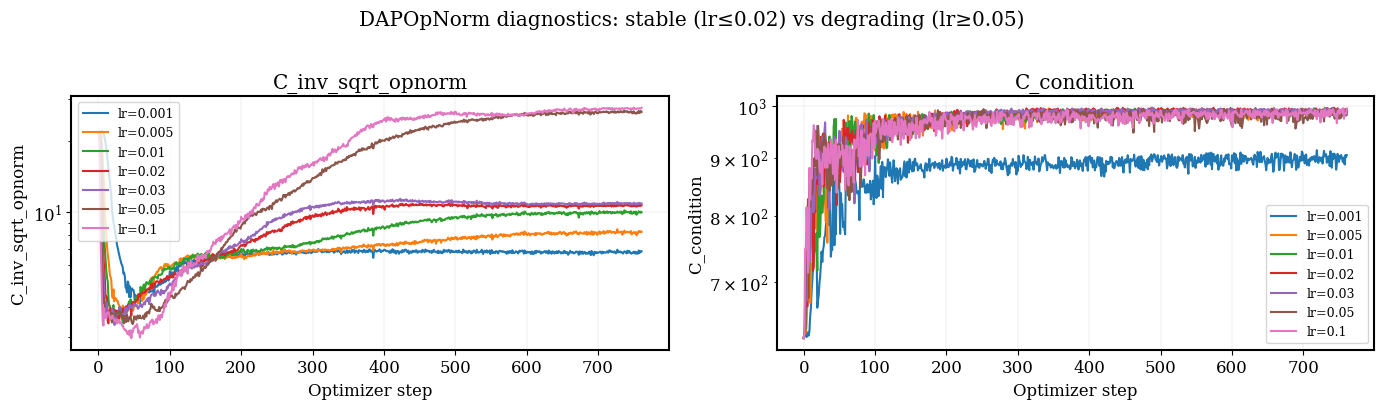

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for key, ax in zip(['C_inv_sqrt_opnorm', 'C_condition'], axes):
    plot_diag_over_steps(diag_outputs, key=key, ax=ax,
                         label_fn=lambda o: o['name'].replace('dap-opnorm-lr-', 'lr='))
    ax.set_title(key)

plt.suptitle('DAPOpNorm diagnostics: stable (lr≤0.02) vs degrading (lr≥0.05)', y=1.02)
plt.tight_layout()
plt.savefig('figures/dap_opnorm_diagnostics_vs_step.pdf', bbox_inches='tight')
plt.show()

## Damping & EMA sweep at lr=0.05: val loss + diagnostics

In [134]:
damping_outputs = load_sweep('configs/finewebmini/dap_opnorm_damping.yaml', 'damping')
ema_outputs     = load_sweep('configs/finewebmini/dap_opnorm_ema.yaml', 'ema_beta')

ref_lr = 0.05
ref_dap  = [o for o in diag_outputs if o['name'] == f'dap-opnorm-lr-{ref_lr}']
ref_muon = [o for o in outputs if o['name'] == f'muon-lr-{ref_lr}']

print('=== Val loss at lr=0.05 ===')
if ref_muon: print(f"  muon (baseline):         {best_val(ref_muon[0]):.4f}")
if ref_dap:  print(f"  dap-opnorm (no fix):     {best_val(ref_dap[0]):.4f}")
print()
print('  --- damping sweep ---')
for o in damping_outputs:
    print(f"  {o['_label']:20s}  {best_val(o):.4f}")
print()
print('  --- ema_beta sweep ---')
for o in ema_outputs:
    print(f"  {o['_label']:20s}  {best_val(o):.4f}")

=== Val loss at lr=0.05 ===
  muon (baseline):         4.7452
  dap-opnorm (no fix):     4.9122

  --- damping sweep ---
  damping=0.01          4.7262
  damping=0.1           4.7785
  damping=0.5           4.9092

  --- ema_beta sweep ---
  ema_beta=0.9          4.9191
  ema_beta=0.95         4.8990
  ema_beta=0.99         4.7965


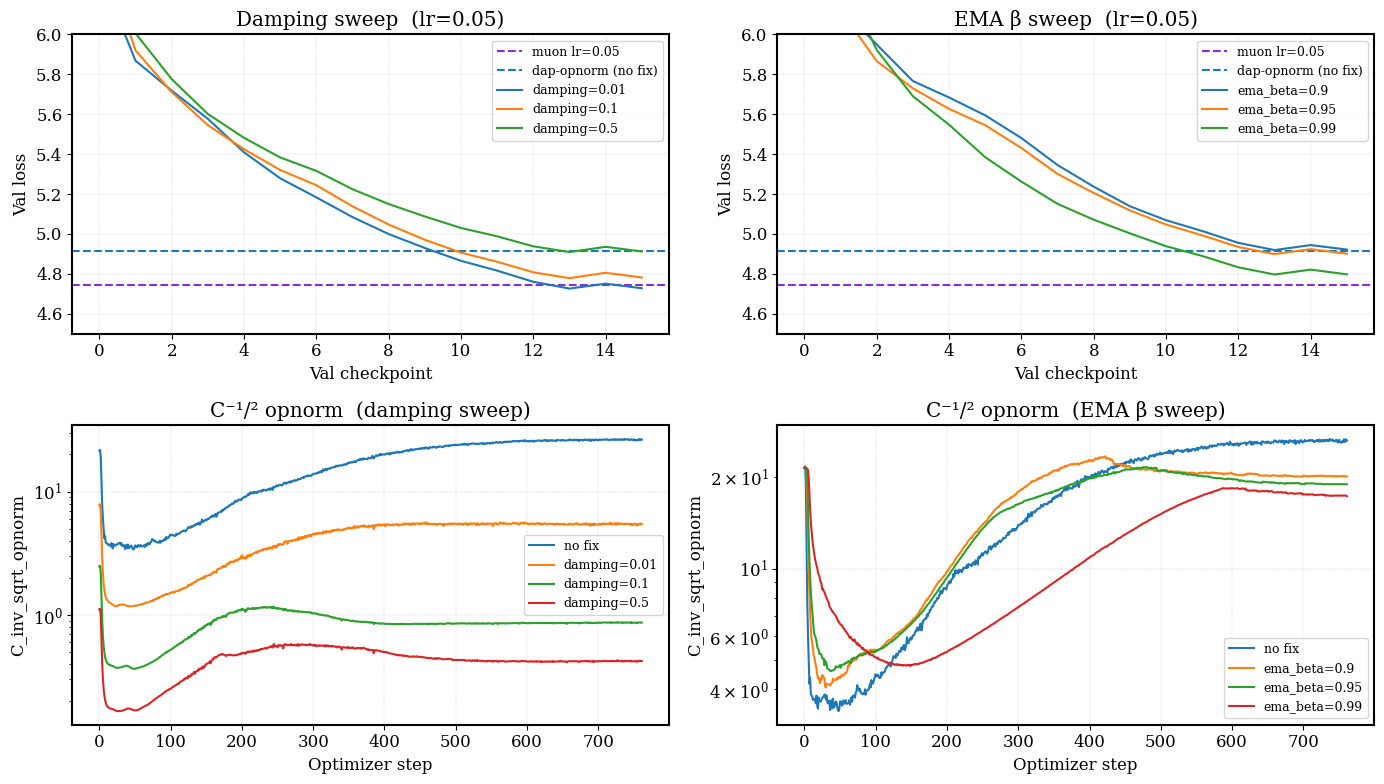

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
(ax_damp_val, ax_ema_val), (ax_damp_diag, ax_ema_diag) = axes

for ax, sweep_outputs, title in [
    (ax_damp_val,  damping_outputs, 'Damping sweep  (lr=0.05)'),
    (ax_ema_val,   ema_outputs,     'EMA β sweep  (lr=0.05)'),
]:
    if ref_muon: ax.axhline(best_val(ref_muon[0]), color='#8A2BE2', ls='--', lw=1.5, label='muon lr=0.05')
    if ref_dap:  ax.axhline(best_val(ref_dap[0]),  color='#1f77b4', ls='--', lw=1.5, label='dap-opnorm (no fix)')
    for o in sweep_outputs:
        ax.plot(o['val_losses'], label=o['_label'])
    ax.set_title(title)
    ax.set_xlabel('Val checkpoint')
    ax.set_ylabel('Val loss')
    ax.set_ylim(4.5, 6.0)
    ax.legend(fontsize=9)
    ax.grid(axis='both', lw=0.2, ls='--')

for ax, sweep_outputs, title in [
    (ax_damp_diag, damping_outputs, 'C⁻¹/² opnorm  (damping sweep)'),
    (ax_ema_diag,  ema_outputs,     'C⁻¹/² opnorm  (EMA β sweep)'),
]:
    if ref_dap:
        plot_diag_over_steps(ref_dap, key='C_inv_sqrt_opnorm', ax=ax,
                             label_fn=lambda o: 'no fix')
    plot_diag_over_steps(sweep_outputs, key='C_inv_sqrt_opnorm', ax=ax,
                         label_fn=lambda o: o['_label'])
    ax.set_title(title)

plt.tight_layout()
plt.savefig('figures/dap_opnorm_sweep_lr005.pdf', bbox_inches='tight')
plt.show()